# Lab 05 - Classification Lab

## Data Story

We are supporting healthcare screening using patient measurements.

Business question:

**Can we classify whether a patient is likely to have diabetes?**

Important note: This is for learning only, not medical diagnosis.

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
df = pd.read_csv("dataset/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1. Understand the Dataset

In [5]:
print("Rows and columns:", df.shape)
display(df.info())
display(df.describe().T)
display(df["Outcome"].value_counts().rename({0: "No Diabetes", 1: "Diabetes"}))

Rows and columns: (768, 9)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Outcome
No Diabetes    500
Diabetes       268
Name: count, dtype: int64

## 2. Visual Story

Compare glucose levels by outcome.

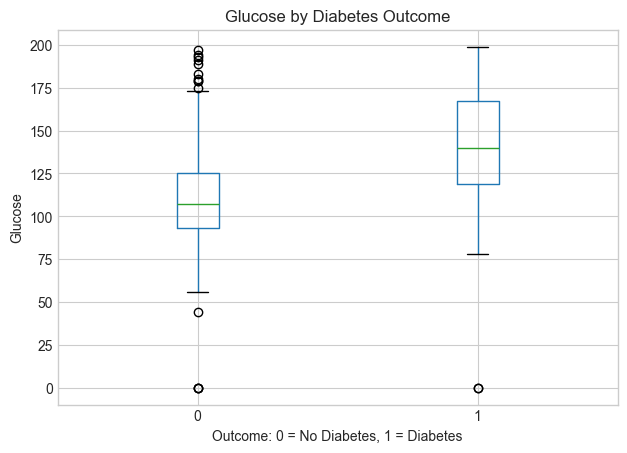

In [7]:
df.boxplot(column="Glucose", by="Outcome", figsize=(7, 5))
plt.title("Glucose by Diabetes Outcome")
plt.suptitle("")
plt.xlabel("Outcome: 0 = No Diabetes, 1 = Diabetes")
plt.ylabel("Glucose")
plt.show()

## 3. Train a Classification Model

In [9]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", round(accuracy, 3))

Accuracy: 0.714


## 4. Explain Model Results

In [10]:
cm = confusion_matrix(y_test, predictions)
cm_df = pd.DataFrame(
    cm,
    index=["Actual No Diabetes", "Actual Diabetes"],
    columns=["Predicted No Diabetes", "Predicted Diabetes"],
)
display(cm_df)
print(classification_report(y_test, predictions))

,Predicted No Diabetes,Predicted Diabetes
Actual No Diabetes,82,18
Actual Diabetes,26,28


              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



## 5. Feature Story

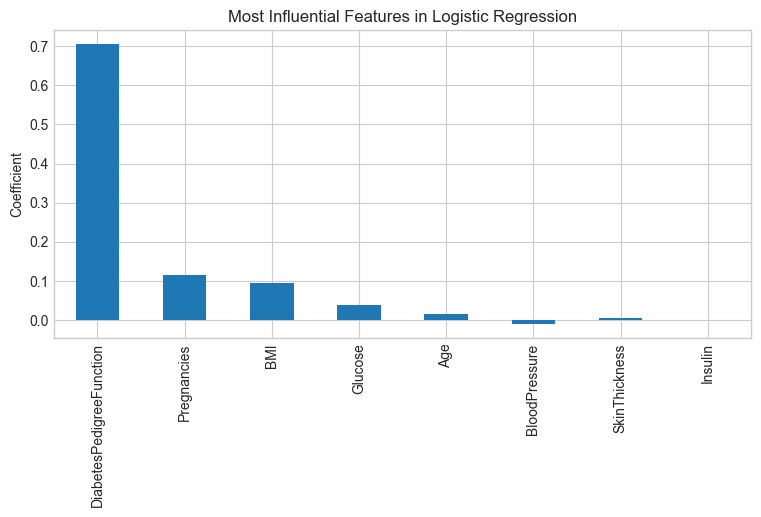

DiabetesPedigreeFunction    0.706082
Pregnancies                 0.114118
BMI                         0.092723
Glucose                     0.036934
Age                         0.015527
BloodPressure              -0.011166
SkinThickness               0.004525
Insulin                    -0.001244
dtype: float64

In [11]:
feature_importance = pd.Series(model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
feature_importance.plot(kind="bar", figsize=(9, 4))
plt.title("Most Influential Features in Logistic Regression")
plt.ylabel("Coefficient")
plt.show()
feature_importance

## 6. Data Storytelling Conclusion

In [12]:
print(f"Story conclusion: The model correctly classified about {accuracy * 100:.1f}% of test cases.")
print("Business action: use this type of model as a screening support tool, not as a final medical decision.")
print("Risk: false negatives and false positives have real consequences, so human review is necessary.")

Story conclusion: The model correctly classified about 71.4% of test cases.
Business action: use this type of model as a screening support tool, not as a final medical decision.
Risk: false negatives and false positives have real consequences, so human review is necessary.
